In [1]:
import numpy as np
import pandas as pd
import pyopenms as ms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from itertools import product
import string
from scipy.signal import find_peaks

# generate data table
Peptide sequences from library generation, generate [M+H]+ and [M+2H]2+

In [2]:
curated_library_unirep = np.load('data/curated_peptide_list.npy')

#Define modifications
linear = 'TAPAYDG'
lin_het_red = 'T[-18.01]APAYDG'
lin_het_ox = 'T[-20.02]APAYDG'
cyc = "TAP[-18.01]"
mods = [linear, lin_het_red, lin_het_ox, cyc]

# create pandas dataframe containing peptide seqs and their mass
df = pd.DataFrame(columns = ['linear', 'L(m+1)', 'L(m+2)', 'L(m+3)',
                             'lin+het+red', 'LHR(m+1)', 'LHR(m+2)','LHR(m+3)', 
                             'lin+het+ox', 'LHO(m+1)', 'LHO(m+2)','LHO(m+3)', 
                             'cyclic', 'C(m+1)', 'C(m+2)', 'C(m+3)'])

for j, pep in enumerate(curated_library_unirep):
    d = []
    for suffix in mods:
        seq_str = pep + suffix
        d.append(seq_str)
        seq = ms.AASequence.fromString(seq_str)
        for i in range(1,4):
            d.append(seq.getMonoWeight(ms.Residue.ResidueType.Full, int(i))/float(i))
    df.loc[j] = d

rows = list(string.ascii_uppercase[:8][::-1])
cols = list(range(1,13))
df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]

In [3]:
df.to_csv('data/peptide_mass_table.csv')
df.head()

,linear,L(m+1),L(m+2),L(m+3),lin+het+red,LHR(m+1),LHR(m+2),LHR(m+3),lin+het+ox,LHO(m+1),LHO(m+2),LHO(m+3),cyclic,C(m+1),C(m+2),C(m+3),well
0,DVQAFTAPAYDG,1254.563716,627.785496,418.859423,DVQAFT[-18.01]APAYDG,1236.553151,618.780214,412.855901,DVQAFT[-20.02]APAYDG,1234.543716,617.775496,412.186090,DVQAFTAP[-18.01],830.404299,415.705788,277.472951,A1
1,GYLKWTAPAYDG,1341.647385,671.327331,447.887313,GYLKWT[-18.01]APAYDG,1323.636820,662.322048,441.883791,GYLKWT[-20.02]APAYDG,1321.627385,661.317331,441.213979,GYLKWTAP[-18.01],917.487969,459.247623,306.500841,A2
2,GAEWRTAPAYDG,1293.585848,647.296562,431.866800,GAEWRT[-18.01]APAYDG,1275.575283,638.291280,425.863279,GAEWRT[-20.02]APAYDG,1273.565848,637.286562,425.193467,GAEWRTAP[-18.01],869.426431,435.216854,290.480328,A3
3,IDFVKTAPAYDG,1296.647051,648.827164,432.887201,IDFVKT[-18.01]APAYDG,1278.636486,639.821881,426.883680,IDFVKT[-20.02]APAYDG,1276.627051,638.817164,426.213868,IDFVKTAP[-18.01],872.487635,436.747456,291.500729,A4
4,WLYKDTAPAYDG,1399.652865,700.330071,467.222473,WLYKDT[-18.01]APAYDG,1381.642300,691.324788,461.218951,WLYKDT[-20.02]APAYDG,1379.632865,690.320071,460.549139,WLYKDTAP[-18.01],975.493449,488.250363,325.836001,A5


In [34]:
def peak_detect(trace, sensitivity=2.0):
    '''peakdetection algorithm to detect peaks of linear peptide and exclude the elution time from other peptides'''
    peaks, properties = find_peaks(trace, distance=100, height=sensitivity*trace.std())
    argmax = properties['peak_heights'].argmax()
    maxpeak = peaks[argmax]
    return(int(maxpeak-10), int(maxpeak+10))
    

[204] 
 {'peak_heights': array([117032.])}
1713


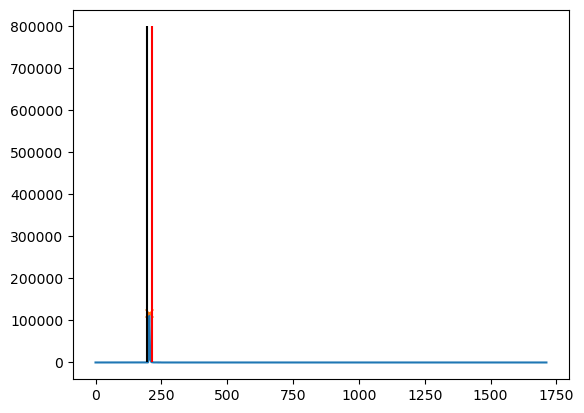

In [12]:
infile='data/PatDf-ArtG/230426-PDF-ArtG-2d-74_Y-G2_1_25392.mzML'
exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
cyclic_ions =  ['C(m+1)', 'C(m+2)', 'C(m+3)']
exp_ions = linear_ions + cyclic_ions
lin_ions = df.loc[38, linear_ions]
ions = df.loc[exp_num, exp_ions] # get the defined ions

lin_ions = df.loc[exp_num, linear_ions] # define linear ions for peak detection
peptide = df.loc[exp_num, 'linear'] # get peptide sequence
ion = ions[0]
exp = ms.MSExperiment()
ms.MzMLFile().load(infile, exp)
N_scans = len(exp.getSpectra())
intensity = np.zeros((len(range(750)), N_scans))
for i in range(N_scans):
    rt = exp.getSpectrum(i).getRT()
    if (rt>20) and (rt<240):
        mass, count = exp.getSpectrum(i).get_peaks()
        mask = (mass > (ion - 0.1)) & (mass < (ion + 0.1))
        ic = count[mask].sum()
        intensity[j,i] = ic
trace=intensity.sum(axis=0)
#x, y = peak_detect(trace,lag=15, threshold=1.5)
peaks, properties = find_peaks(trace, distance=100, height=trace.std())

plt.plot(trace)
plt.plot(peaks, trace[peaks], 'x')

plt.vlines(peaks[properties['peak_heights'].argmax()]-10,ymin=0,ymax=800000, colors='k')
plt.vlines(peaks[properties['peak_heights'].argmax()]+10,ymin=0,ymax=800000, colors='r')

print(peaks, '\n', properties)
print(N_scans)

In [38]:
def extract_ioncount(exp, ions, rt_start, rt_end, MZ_tol=0.1):
    '''
    returns list of extracted ion counts of an mzML and
    intensity over time for a given spectrum 
    exp : [pyOpenMS experiment]
    ions: iterable of desired ion m/z values [float]
    rt_start: start acquisition retentiontime [seconds]
    rt_end: end acquisition retentiontime [seconds]
    MZ_tol: tolerance interval for m/z [float]
    '''
    N_scans = len(exp.getSpectra())
    ionCounts = np.zeros(len(ions))
    if PLOT==True:
        intensity = np.zeros((len(ions), N_scans))
    else: 
        intensity = None
        
    for j, ion in enumerate(ions):
        for i in range(N_scans):
            rt = exp.getSpectrum(i).getRT()
            if (rt>rt_start) and (rt<rt_end):
                mass, count = exp.getSpectrum(i).get_peaks()
                mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                ic = count[mask].sum()
                ionCounts[j] += ic
                
                if PLOT==True:
                    intensity[j,i] = ic
         
    return(list(ionCounts), intensity)

In [67]:
def extract_ioncount2(exp, ions, rt_start, rt_end, MZ_tol=0.1, sensitivity=3):
    '''
    returns list of extracted ion counts of an mzML and
    intensity over time for a given spectrum 
    exp : [pyOpenMS experiment]
    ions: iterable of desired ion m/z values [float]
    rt_start: start acquisition retentiontime [seconds]
    rt_end: end acquisition retentiontime [seconds]
    MZ_tol: tolerance interval for m/z [float]
    '''
    N_scans = len(exp.getSpectra())
    ionCounts = np.zeros(len(ions))
    
    intensity = np.zeros((len(ions), N_scans))
            
    for j, ion in enumerate(ions):
        if j <= 2:
            for i in range(N_scans):
                rt = exp.getSpectrum(i).getRT()
                if (rt>rt_start) and (rt<rt_end):
                    mass, count = exp.getSpectrum(i).get_peaks()
                    mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                    ic = count[mask].sum()
                    intensity[j,i] = ic
            x1, x2 =  peak_detect(intensity.sum(axis=0), sensitivity=sensitivity)
        else:
            for i in range(N_scans):
                rt = exp.getSpectrum(i).getRT()
                if (rt>rt_start) and (rt<rt_end):
                    mass, count = exp.getSpectrum(i).get_peaks()
                    mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                    ic = count[mask].sum()
                    intensity[j,i] = ic
        intensity[3:, x1:x2] = 0.0
        ionCounts = intensity.sum(axis=1)
    return(list(ionCounts), intensity)

In [48]:
def make_heatmap(data, name, incubation_time, quantity='conversion'):
    rows = list(string.ascii_uppercase[:8][::-1])
    cols = list(range(1,13))
    quantity = 'conversion'

    data = np.array(result_df['conversion']).reshape((8,12))

    fig, ax = plt.subplots()
    im = ax.imshow(data, extent=[0, 12, 0, 8] )
    #ax.pcolormesh(data, edgecolors='k', linewidth=2)
    ax.grid(which = 'minor',color='w', linestyle='-', linewidth=2)
    plt.xticks(np.arange(len(cols))+0.5, labels=cols)
    ax.set_yticks(np.arange(len(rows))+0.5, labels=rows)
    plt.xlim(0,12)
    plt.title(name+' '+quantity+', '+incubation_time)

    #ax.grid(color='k', linestyle='-', linewidth=2)
    for j, i in product(np.arange(len(cols)),np.arange(len(rows))):
        l = ax.axvline(j, color='k', linewidth=2)
        l = ax.axhline(i, color='k', linewidth=2)

    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.028, pad=0.04)
    cbar.ax.set_ylabel('% '+quantity, rotation=-90, va="bottom")

# Analyze PatG - 2 day reaction

In [68]:
PLOT=True
data_dir = 'data/PatG-2d/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
cyclic_ions =  ['C(m+1)', 'C(m+2)', 'C(m+3)']
exp_ions = linear_ions + cyclic_ions

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = int(0.4*60)
end = 240

In [ ]:
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    lin_ions = df.loc[exp_num, linear_ions] # define linear ions for peak detection
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    #ion_count, intensity = extract_ioncount(exp, ions, start, end)
    ion_count, intensity = extract_ioncount2(exp, ions, start, end)
    
    if PLOT==True:
        for i in range(len(ions)):
            col = ['r', 'b']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            else:
                plt.plot(intensity[i], color = col[1])
        plt.xlabel('Scans')
        plt.ylabel('Intensity')
        plt.title('PatG + '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='cyclic peptide')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch])
        plt.savefig('output_patg/'+str(exp_num)+'_PatG_'+peptide)
        plt.clf()

    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['C(tot)'] = result_df.loc[:,['C(m+1)', 'C(m+2)', 'C(m+3)']].sum(axis=1)

# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,'C(tot)']/result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)*100

In [ ]:
# sort again by index
result_df.sort_index(inplace=True)
# add names for wells to the data
rows = list(string.ascii_uppercase[:8][::-1])
cols = list(range(1,13))
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]

# calculate total ion count of all linear and cyclic peptides
result_df['tot_ions'] = result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)
result_df.head()

## False positive filtering
Crosscompare the total ion count with conversion values. Spectra were sorted by total ion count and all spectra were visually checked. 

**Observation**: Measurements with a total ion count < 1739627.0 seemed to be of poor quality and need to be repeated.

In [ ]:
result_df.sort_values('tot_ions').head(14)

In [ ]:
result_df.loc[:,['conversion', 'tot_ions']].hist(bins=20)

**Observation:** The top conversions stemmed from low ion count measurements. 

In [ ]:
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

__filter out samples with low ion count__

In [ ]:
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < 1739627.0, 'conversion'] = 0
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

In [ ]:
make_heatmap(result_df, 'PatG', '2 days','conversion')

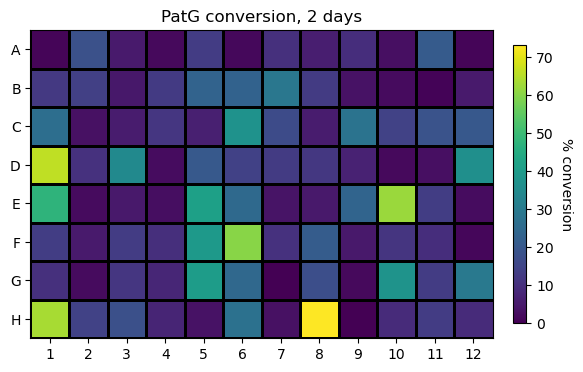

In [56]:
make_heatmap(result_df, 'PatG', '2 days','conversion')

## top 10 candidates for cyclization with PatG

In [15]:
result_df.to_csv('PatG-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['peptide','conversion']].head(10)

,peptide,conversion
65,ARYFQTAPAYDG,40.858831
91,WHRFTTAPAYDG,37.197500
84,IFRYETAPAYDG,31.298420
57,HRFLWTAPAYDG,26.472862
36,YRGAWTAPAYDG,25.252496
89,YLEKFTAPAYDG,19.838374
29,VENWYTAPAYDG,19.067205
38,QRWETTAPAYDG,17.799838
48,GRFYKTAPAYDG,16.475558
78,YGENWTAPAYDG,16.343493


# Analyze PatDfusion + ArtGox - 2 day reaction

In [15]:
PLOT=False
data_dir = 'data/PatDf-ArtG/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
lhr = ['LHR(m+1)', 'LHR(m+2)','LHR(m+3)']
lho = ['LHO(m+1)', 'LHO(m+2)','LHO(m+3)' ]

#combined list with expected ions
exp_ions = linear_ions + lhr + lho

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = int(0.4*60)
end = 240

In [16]:
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    ion_count, intensity = extract_ioncount(exp, ions, start, end)
    
    if PLOT==True:
        for i in range(len(ions)):
            col = ['r', 'b', 'k']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            elif i >= 6:
                plt.plot(intensity[i], color = col[2])
            else:
                plt.plot(intensity[i], color = col[1])
        plt.xlabel('Scans')
        plt.ylabel('Intensity')
        plt.title('PatDf+ArtGox + '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='heterocyclic reduced')
        black_patch = mpatches.Patch(color='k', label='heterocyclic oxidized')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch, black_patch])
        plt.savefig('output_patdf_artgox/'+str(exp_num)+'_PatDf_ArtGox_'+peptide)
        plt.clf()
            
    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['LHR(tot)'] = result_df.loc[:,lhr].sum(axis=1)
result_df['LHO(tot)'] = result_df.loc[:,lho].sum(axis=1)

# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,['LHO(tot)','LHR(tot)']].sum(axis=1)/result_df.loc[:,['LHO(tot)', 'LHR(tot)', 'L(tot)']].sum(axis=1)*100
result_df['tot_ions'] = result_df.loc[:, exp_ions].sum(axis=1)

result_df.sort_values('tot_ions').head(10)

,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),conversion,tot_ions
94,ENFRDTAPAYDG,7032.0,200843.0,122031.0,7519.0,93770.0,89881.0,8580.0,63971.0,75545.0,329906.0,191170.0,148096.0,50.699372,669172.0
3,IDFVKTAPAYDG,14814.0,324168.0,121841.0,9057.0,160811.0,135766.0,10264.0,99929.0,511969.0,460823.0,305634.0,622162.0,66.814295,1388619.0
10,QFWKVTAPAYDG,11781.0,277895.0,357422.0,14133.0,248797.0,235623.0,13870.0,114994.0,142570.0,647098.0,498553.0,271434.0,54.335978,1417085.0
23,DQFWHTAPAYDG,2922.0,352249.0,111846.0,1951.0,273896.0,91280.0,1076.0,250572.0,423085.0,467017.0,367127.0,674733.0,69.048703,1508877.0
0,DVQAFTAPAYDG,15323.0,116145.0,243585.0,23009.0,145245.0,144363.0,22585.0,244661.0,886875.0,375053.0,312617.0,1154121.0,79.636506,1841791.0
25,ADKFETAPAYDG,15686.0,1686943.0,91980.0,16558.0,218111.0,75778.0,3067.0,39466.0,211167.0,1794609.0,310447.0,253700.0,23.917141,2358756.0
92,FAKIYTAPAYDG,27654.0,2544679.0,111889.0,3075.0,59181.0,30388.0,2096.0,24619.0,22911.0,2684222.0,92644.0,49626.0,5.033448,2826492.0
9,LDWEFTAPAYDG,438920.0,4638345.0,52504.0,32265.0,276021.0,20440.0,2096.0,53902.0,8091.0,5129769.0,328726.0,64089.0,7.112884,5522584.0
86,EYWNATAPAYDG,1368004.0,3656905.0,306446.0,41347.0,273339.0,628473.0,2721.0,98872.0,65288.0,5331355.0,943159.0,166881.0,17.232913,6441395.0
37,ERVQKTAPAYDG,17817.0,1394290.0,4805187.0,1463.0,305204.0,307487.0,878.0,31380.0,51426.0,6217294.0,614154.0,83684.0,10.091463,6915132.0


In [17]:
result_df.sort_index(inplace=True)
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]
result_df.sort_values('tot_ions', ascending=True).head()

,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),conversion,tot_ions,well
94,ENFRDTAPAYDG,7032.0,200843.0,122031.0,7519.0,93770.0,89881.0,8580.0,63971.0,75545.0,329906.0,191170.0,148096.0,50.699372,669172.0,H11
3,IDFVKTAPAYDG,14814.0,324168.0,121841.0,9057.0,160811.0,135766.0,10264.0,99929.0,511969.0,460823.0,305634.0,622162.0,66.814295,1388619.0,A4
10,QFWKVTAPAYDG,11781.0,277895.0,357422.0,14133.0,248797.0,235623.0,13870.0,114994.0,142570.0,647098.0,498553.0,271434.0,54.335978,1417085.0,A11
23,DQFWHTAPAYDG,2922.0,352249.0,111846.0,1951.0,273896.0,91280.0,1076.0,250572.0,423085.0,467017.0,367127.0,674733.0,69.048703,1508877.0,B12
0,DVQAFTAPAYDG,15323.0,116145.0,243585.0,23009.0,145245.0,144363.0,22585.0,244661.0,886875.0,375053.0,312617.0,1154121.0,79.636506,1841791.0,A1


In [18]:
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)','conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,2.183605e+07,1.691171e+06,2.591393e+05,10.621371,2.378636e+07
std,1.276345e+07,1.857516e+06,2.897108e+05,13.780730,1.409841e+07
min,3.299060e+05,9.264400e+04,3.286400e+04,3.089489,6.691720e+05
25%,1.298034e+07,6.319980e+05,1.051158e+05,5.034225,1.387730e+07
50%,2.048314e+07,1.116634e+06,1.652910e+05,6.192059,2.209291e+07
75%,2.786823e+07,2.069885e+06,2.873242e+05,8.648481,3.023524e+07
max,6.093378e+07,1.232108e+07,2.154369e+06,79.636506,6.662361e+07


In [21]:
cutoff = 4826505.0
quantity = 'conversion'
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < cutoff, quantity] = 0
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)', 'unfiltered_conversion', 'conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),unfiltered_conversion,conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,96.000000,9.600000e+01
mean,2.183605e+07,1.691171e+06,2.591393e+05,10.093252,6.980898,2.378636e+07
std,1.276345e+07,1.857516e+06,2.897108e+05,13.187355,5.128875,1.409841e+07
min,3.299060e+05,9.264400e+04,3.286400e+04,0.000000,0.000000,6.691720e+05
25%,1.298034e+07,6.319980e+05,1.051158e+05,5.032562,4.641375,1.387730e+07
50%,2.048314e+07,1.116634e+06,1.652910e+05,6.144698,5.808218,2.209291e+07
75%,2.786823e+07,2.069885e+06,2.873242e+05,8.456303,7.960949,3.023524e+07
max,6.093378e+07,1.232108e+07,2.154369e+06,79.636506,33.517465,6.662361e+07


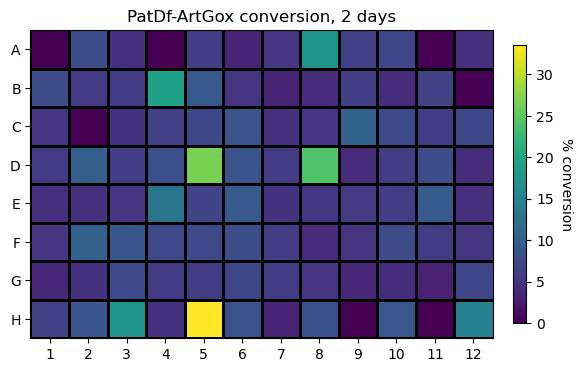

In [22]:
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion')

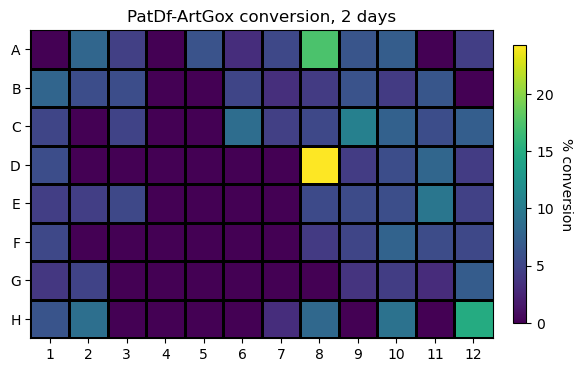

In [29]:
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion')

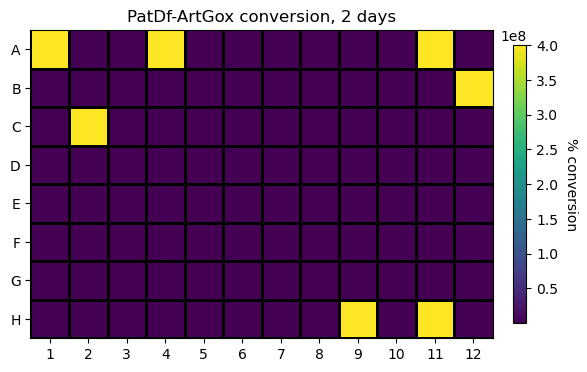

In [12]:
result_df.loc[result_df['tot_ions'] < cutoff, quantity] = 400000000
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion')

In [23]:
result_df[result_df['conversion']>3e+08].sort_values('well')['well'].to_csv('lowcount_patdf.csv')

In [21]:
result_df.to_csv('result_data/PatDf-ArtGox-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['conversion','peptide','well']].head(10)

,conversion,peptide,well
88,33.517465,YEIAYTAPAYDG,H5
40,26.641351,NFRAFTAPAYDG,D5
43,24.230999,KWENFTAPAYDG,D8
15,19.224160,VIALYTAPAYDG,B4
7,17.324383,YVLRYTAPAYDG,A8
86,17.232913,EYWNATAPAYDG,H3
95,14.899716,FIRYQTAPAYDG,H12
51,12.876283,WDLKYTAPAYDG,E4
32,10.575966,VKFWHTAPAYDG,C9
61,10.338727,RFIWATAPAYDG,F2


In [ ]:
result_df.sort_values('conversion', ascending=False).loc[:,['peptide','conversion']].to_csv('result_data/PatDf-ArtGox-ranking.csv')

linear                 NFRAFTAPAYDG
L(m+1)                  1329.622233
L(m+2)                   665.314755
L(m+3)                   443.878929
lin+het+red    NFRAFT[-18.01]APAYDG
LHR(m+1)                1311.611668
LHR(m+2)                 656.309472
LHR(m+3)                 437.875407
lin+het+ox     NFRAFT[-20.02]APAYDG
LHO(m+1)                1309.602233
LHO(m+2)                 655.304755
LHO(m+3)                 437.205595
cyclic             NFRAFTAP[-18.01]
C(m+1)                   905.462816
C(m+2)                   453.235046
C(m+3)                   302.492456
well                             D5
Name: 40, dtype: object